# Хосты и спрос


Цель данного ноутбука - сопоставить структуру хостов с ценой, условиями размещения и признаками текущего спроса, чтобы понять, насколько крупные игроки отличаются от основной массы рынка.


## Загрузка библиотек и установка настроек


In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Загрузка аналитического набора данных


In [2]:
listings = pd.read_parquet("../data/processed/listings_analytics.parquet")


## Проверка гипотез


### Гипотеза 1. Небольшое число крупных хостов удерживает заметную долю предложения


(0.0, 0.5431697054698457)

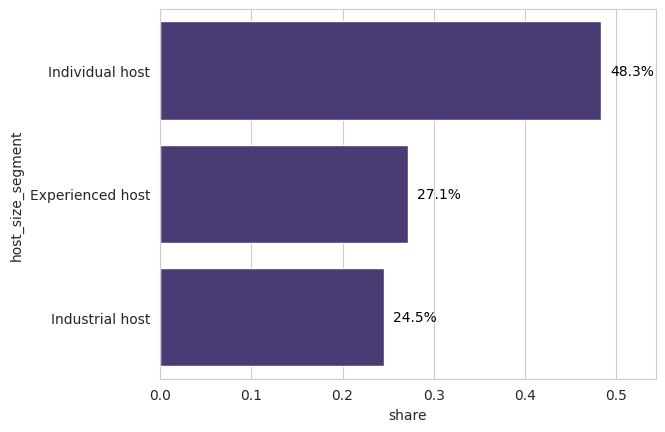

In [3]:
shares = (
    listings["host_size_segment"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .sort_values("share", ascending=False)
)

ax = sns.barplot(data=shares, x="share", y="host_size_segment")

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.01,
        p.get_y() + p.get_height() / 2,
        f"{width:.1%}",
        va="center",
        ha="left",
        color="black",
    )

ax.set_xlim(0, shares["share"].max() + 0.06)


(0.0, 0.88429140580535)

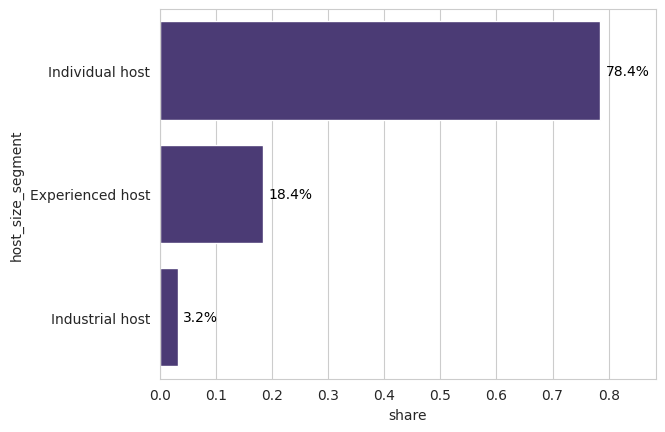

In [4]:
hosts = listings[["host_id", "host_size_segment"]].drop_duplicates()

shares_hosts = (
    hosts["host_size_segment"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .sort_values("share", ascending=False)
)

ax = sns.barplot(data=shares_hosts, x="share", y="host_size_segment")

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.01,
        p.get_y() + p.get_height() / 2,
        f"{width:.1%}",
        va="center",
        ha="left",
        color="black",
    )

ax.set_xlim(0, shares_hosts["share"].max() + 0.1)


По числу объявлений рынок выглядит относительно сбалансированным, однако индивидуальные владельцы составляют примерно *78.4%* всех хостов, тогда как индустриальный сегмент - лишь около *3.2%*. Следовательно, значимая часть предложения действительно сосредоточена у небольшого числа крупных игроков.


### Гипотеза 2. Чем крупнее хост, тем заметнее его присутствие внутри типологии жилья


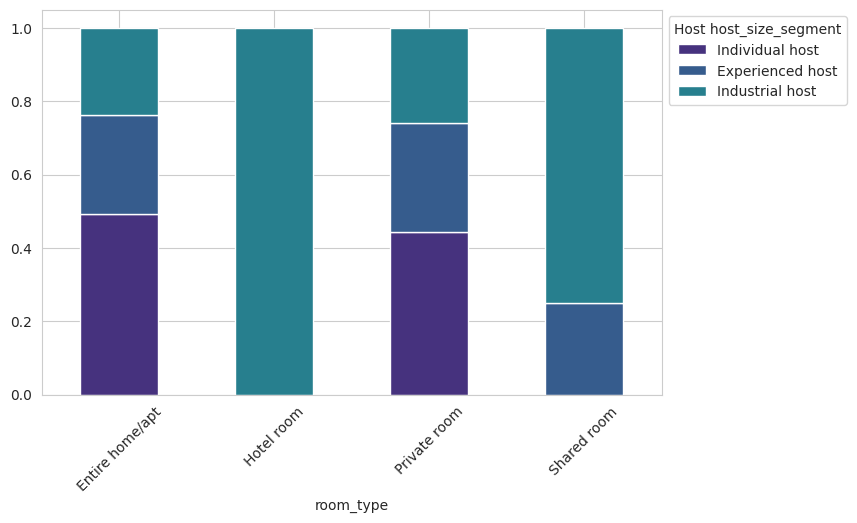

In [5]:
ct = pd.crosstab(
    index=listings["room_type"],
    columns=listings["host_size_segment"],
    normalize="index",
)

ct.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.xticks(rotation=45)
plt.legend(title="Host host_size_segment", bbox_to_anchor=(1, 1))


Во всех массовых типах жилья заметно присутствие трёх сегментов хостов, однако внутри `Entire home/apt` и `Private room` на индустриальный сегмент всё же приходится около четверти объектов. Категории `Hotel room` и `Shared room` из-за единичного числа наблюдений не следует оценивать.


### Гипотеза 3. Крупные хосты удерживают более высокий ценовой уровень внутри сегментов


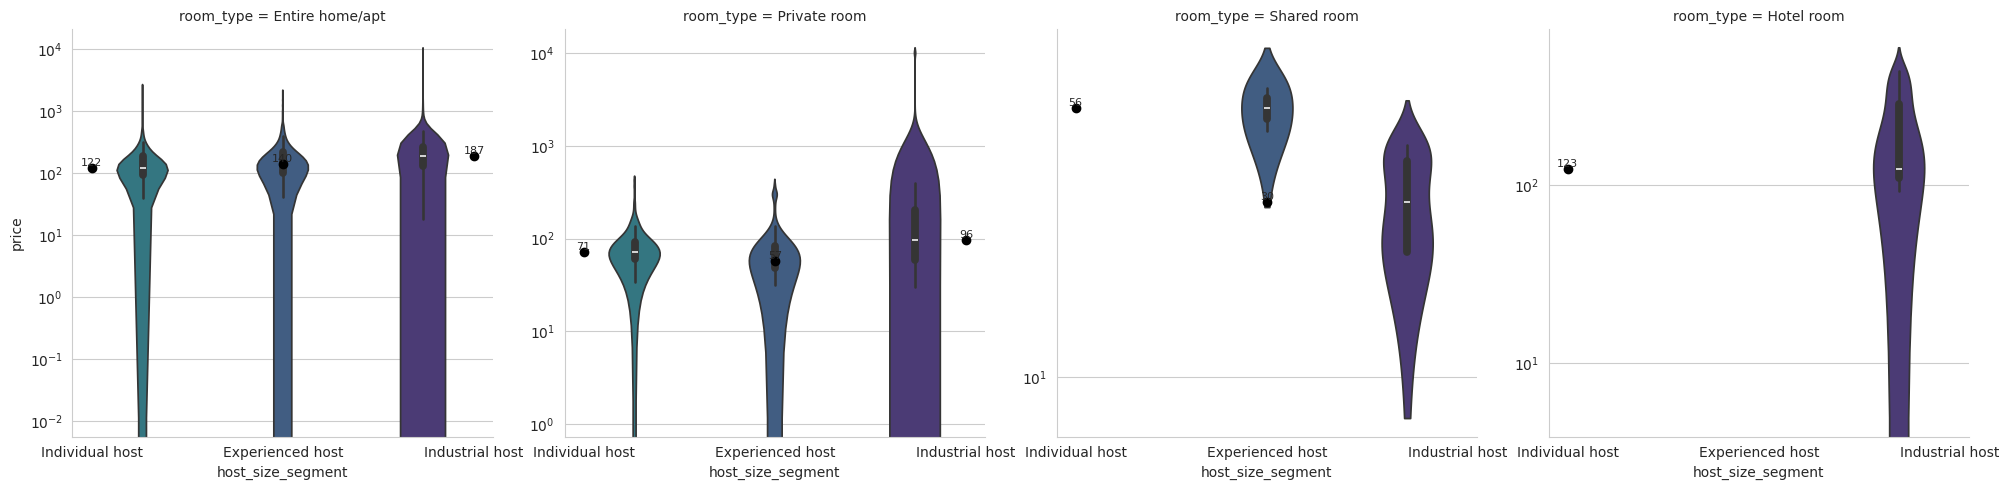

In [6]:
g = sns.catplot(
    data=listings,
    x="host_size_segment",
    y="price",
    hue="host_size_segment",
    col="room_type",
    kind="violin",
    sharey=False,
)

for ax, room in zip(g.axes.flat, listings["room_type"].unique()):
    sub = listings[listings["room_type"] == room]
    medians = sub.groupby("host_size_segment")["price"].median()

    for i, (seg, val) in enumerate(medians.items()):
        ax.scatter(i, val, color="black", zorder=3)
        ax.text(i, val, f"{val:.0f}", ha="center", va="bottom", fontsize=8)

    ax.set_yscale("log")


Вывод: Крупные игроки чаще работают в более дорогом сегменте внутри `Entire home/apt`, а в `Private room` различия тоже заметны, хотя слабее. Эффект сохраняется и после возврата ценовых выбросов, то есть не сводится только к редким экстремальным ценам.


### Гипотеза 4. Крупные хосты задают более жёсткие требования по минимальному сроку аренды


<Axes: xlabel='host_size_segment', ylabel='minimum_nights'>

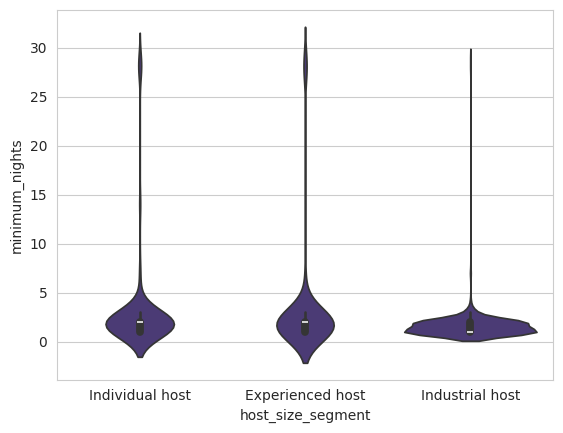

In [7]:
sns.violinplot(
    data=listings[
        listings["minimum_nights"] < listings["minimum_nights"].quantile(0.99)
    ],
    x="host_size_segment",
    y="minimum_nights",
)


Вывод: Крупные хосты скорее снижают порог входа, чем усиливают ограничения.


### Гипотеза 5. Более крупные хосты эффективнее удерживают текущий спрос


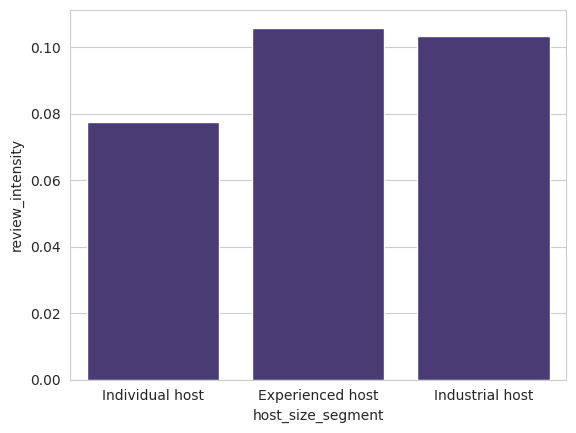

In [8]:
sns.barplot(
    data=listings.groupby("host_size_segment", as_index=False)["review_intensity"]
    .median()
    .sort_values(by="review_intensity", ascending=False),  # type: ignore
    x="host_size_segment",
    y="review_intensity",
)
plt.show()


<Axes: xlabel='number_of_reviews', ylabel='review_intensity'>

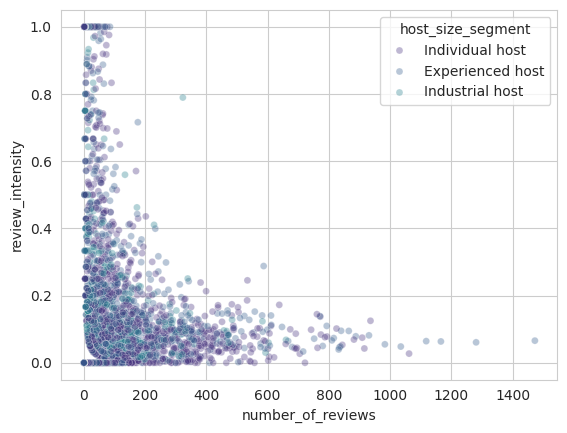

In [9]:
sns.scatterplot(
    data=listings,
    x="number_of_reviews",
    y="review_intensity",
    hue="host_size_segment",
    alpha=0.35,
    s=25,
)


Вывод: Крупные и средние сегменты немного лучше поддерживают свежую отзывную активность.


### Гипотеза 6. Доступность и свежесть спроса связаны между собой


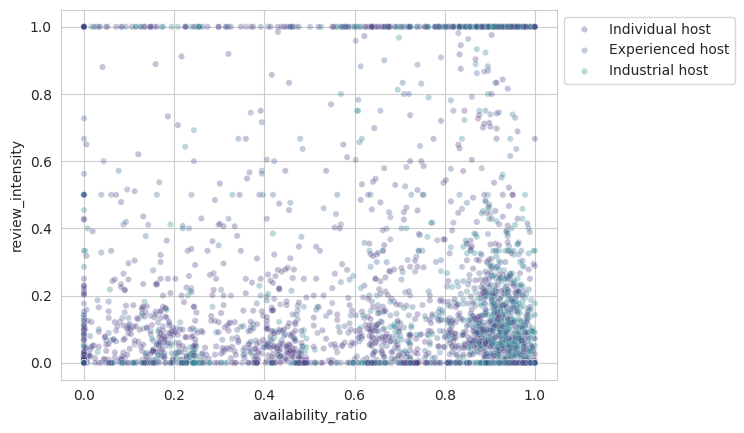

In [10]:
sns.scatterplot(
    data=listings,
    x="availability_ratio",
    y="review_intensity",
    hue="host_size_segment",
    alpha=0.3,
    s=20,
)

plt.legend(bbox_to_anchor=(1, 1))


Вывод: Высокая доступность не означает автоматически более слабый спрос.


### Гипотеза 7. География спроса различается по сегментам хостов


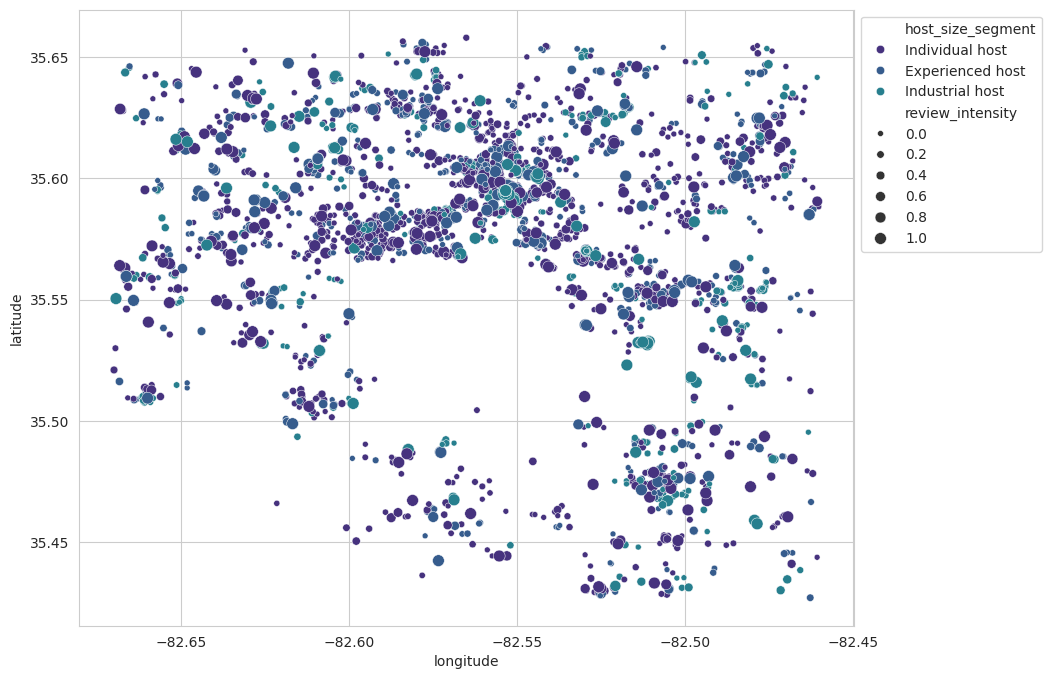

In [11]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=listings,
    x="longitude",
    y="latitude",
    size="review_intensity",
    hue="host_size_segment",
)
plt.legend(bbox_to_anchor=(1, 1))


Вывод: Крупные хосты заметнее в городских зонах, но не образуют отдельной изолированной географии.


### Гипотеза 8. Отсутствие цены связано с географией или типом размещения


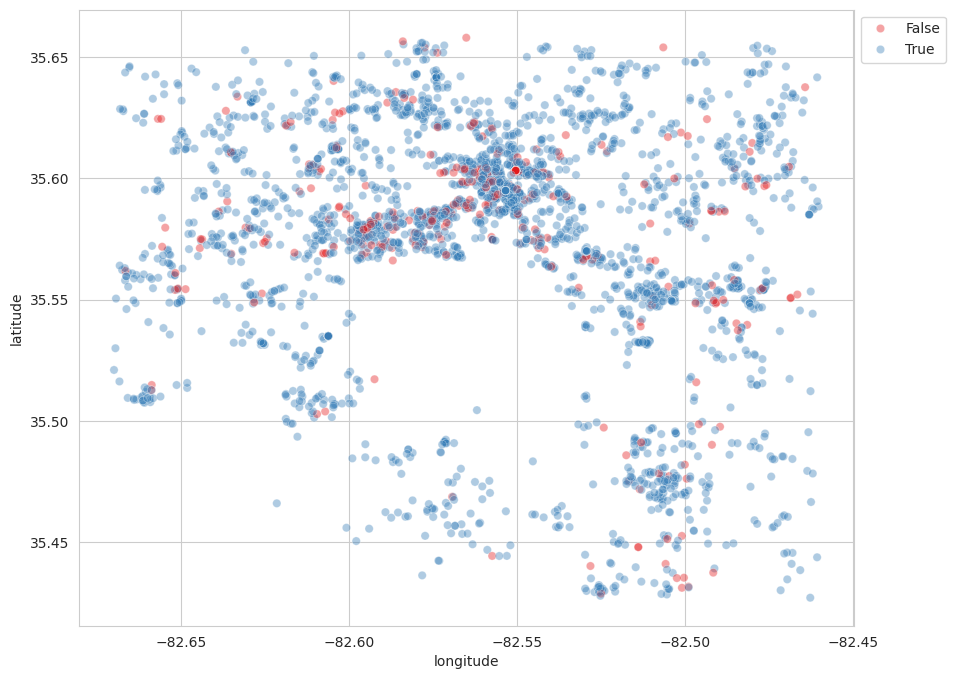

In [12]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=listings,
    x="longitude",
    y="latitude",
    hue="has_price",
    palette="Set1",
    alpha=0.4
)
plt.legend(bbox_to_anchor=(1, 1))


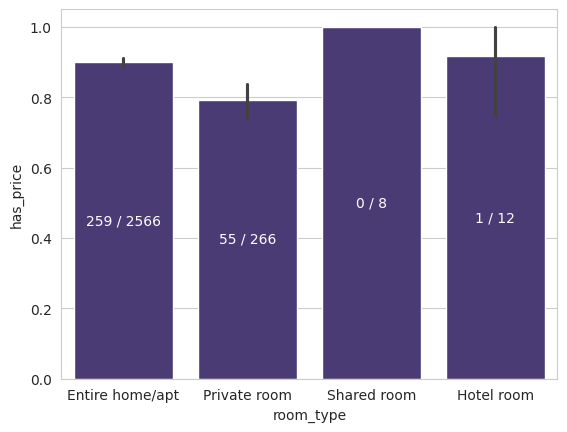

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(data=listings, x="room_type", y="has_price")

agg = listings.groupby("room_type").agg(
    no_price=("has_price", lambda x: (x == 0).sum()), total=("has_price", "count")
)

for i, category in enumerate(ax.get_xticklabels()):
    room = category.get_text()
    no_price = agg.loc[room, "no_price"]
    total = agg.loc[room, "total"]

    height = ax.patches[i].get_height()  # type: ignore

    ax.text(
        i, height / 2, f"{no_price} / {total}", ha="center", va="center", color="white"
    )

plt.show()


Среди `Private room` цена отсутствует заметно чаще, чем среди `Entire home/apt`, тогда как по районам различия более умеренные, хотя зоны `28801` и `28806` выделяются повышенной долей объявлений без цены. Пропуски в `price` сильнее связаны с форматом предложения, чем с точкой на карте.


## Промежуточные выводы
Сегментация хостов помогает объяснить различия в структуре предложения и частично в динамике спроса.

1. Рынок формально состоит в основном из индивидуальных хостов, но значимая часть предложения сконцентрирована у небольшого числа крупных хостов.
2. Крупные хосты чаще работают в более дорогом ценовом слое и одновременно задают более короткий порог минимального проживания, а не более жёсткий.
3. Свежесть спроса у крупных и средних сегментов несколько выше, но зависимость между доступностью и отзывной интенсивностью остаётся слабой.
